____
# Hotel Revenue & Cancellation Analysis (ADR, Lead Time, Seasonality)# 
**This project explores booking demand, cancellation drivers, pricing behavior, and operational patterns in City Hotel and Resort Hotel**
____

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [129]:
df_hotel = pd.read_csv("hotel_bookings.csv")

## Business Context and Objectives

This analysis aims to answer four business questions:
1. When are demand peaks and low seasons?
2. What factors are most associated with cancellations?
3. Which segments and channels generate the most value?
4. What operational patterns affect revenue and service?

_____
## Dataset Overview
This section introduces the structure of the dataset and its main variables.
_____

In [133]:
df_hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [135]:
df_hotel.head().style

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.000000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,nan,nan,0,Transient,0.000000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.000000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,nan,nan,0,Transient,0.000000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.000000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,nan,nan,0,Transient,75.000000,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.000000,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.000000,nan,0,Transient,75.000000,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.000000,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.000000,nan,0,Transient,98.000000,0,1,Check-Out,2015-07-03


____
* The dataset contains booking records for both City Hotel and Resort Hotel, including reservation timing, guest composition, pricing, cancellation status, booking channel, and operational variables.
____

____
## Data Cleaning and Quality Notes
This section reviews missing values, duplicated rows, and invalid bookings before starting the exploratory analysis.
____


In [139]:
df_hotel.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [141]:
df_hotel.duplicated().sum()

31994

___
* *Fully duplicated rows were detected, but they were retained due to the absence of a unique booking identifier.*
____

In [144]:
# fill missing values

df_hotel["country"] = df_hotel["country"].fillna("Unknown")
df_hotel["children"] = df_hotel["children"].fillna(0).astype(int) 

df_hotel["agent"] = df_hotel["agent"].astype("Int64").astype("string").fillna("No agent")
df_hotel["company"] = df_hotel["company"].astype("Int64").astype("string").fillna("No company")

In [146]:
# checking results
df_hotel[["country","children","agent","company"]].isnull().sum()

country     0
children    0
agent       0
company     0
dtype: int64

In [148]:
# Remove rows with zero total guests
df_hotel = df_hotel[~((df_hotel["adults"] == 0) & (df_hotel["children"] == 0) & (df_hotel["babies"] == 0))]

In [150]:
# check null data removed
df_hotel.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

____
* After cleaning, missing values were addressed, invalid zero-guest bookings were removed, and duplicated rows were retained because they may represent valid bookings with identical attributes.
____

___
# Exploratory Data Analysis
The EDA is organized into four business-focused sections: demand and seasonality, cancellation drivers, value drivers, and operational insights.
___

## 1. Demand and Seasonality
This section compares booking volume between hotel types and identifies seasonal demand patterns_

In [155]:
# Split dataset by hotel type
df_resort = df_hotel[df_hotel["hotel"] == "Resort Hotel"].copy()
df_city = df_hotel[df_hotel["hotel"] == "City Hotel"].copy()

### 1.1 Booking Volume by Hotel Type

In [159]:
df_city["hotel"].value_counts()

hotel
City Hotel    79163
Name: count, dtype: int64

In [161]:
df_resort["hotel"].value_counts()

hotel
Resort Hotel    40047
Name: count, dtype: int64

___
* By counting the values in the hotel column, we can identify the total number of bookings for each hotel type, allowing us to compare booking volume between City Hotel and Resort Hotel. The results show that City Hotel has a higher number of total bookings than Resort Hotel.
___

### 1.2 Monthly Demand Patterns

In [166]:
# Order months correctly
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Monthly bookings by hotel type
monthly_bookings = (
    df_hotel.groupby(["hotel", "arrival_date_month"])
    .size()
    .reset_index(name="bookings")
)

monthly_bookings["arrival_date_month"] = pd.Categorical(
    monthly_bookings["arrival_date_month"],
    categories=month_order,
    ordered=True
)

monthly_bookings = monthly_bookings.sort_values(["hotel", "arrival_date_month"])
monthly_bookings

monthly_bookings = monthly_bookings.reset_index(drop=True)
monthly_bookings

,hotel,arrival_date_month,bookings
0,City Hotel,January,3730
1,City Hotel,February,4950
2,City Hotel,March,6434
3,City Hotel,April,7469
4,City Hotel,May,8221
5,City Hotel,June,7885
6,City Hotel,July,8071
7,City Hotel,August,8967
8,City Hotel,September,7392
9,City Hotel,October,7594


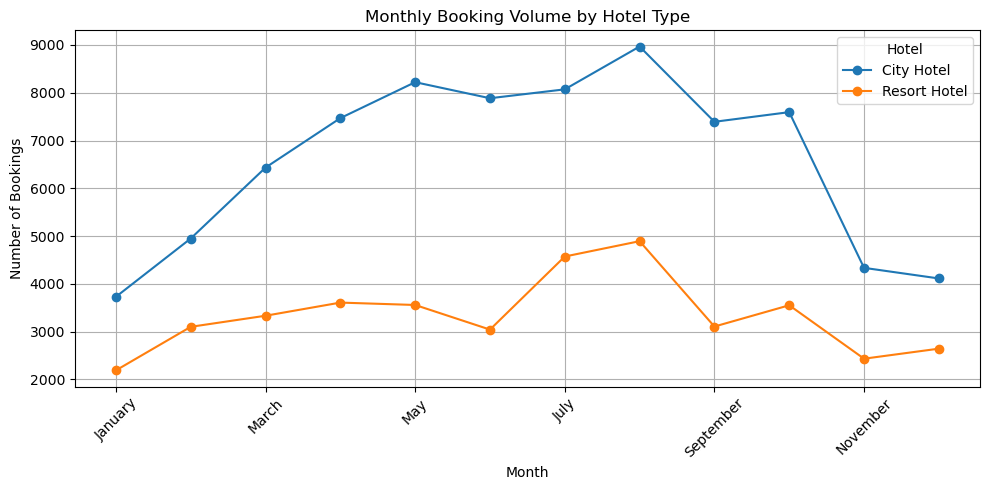

In [168]:
# Pivot table for plotting
monthly_plot = monthly_bookings.pivot(
    index="arrival_date_month",
    columns="hotel",
    values="bookings"
)

# Plot
monthly_plot.plot(marker="o", figsize=(10, 5))

plt.title("Monthly Booking Volume by Hotel Type")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Hotel")
plt.tight_layout()
plt.show()

___
 * Monthly booking volume shows that both hotel types follow a seasonal pattern. August is the strongest month for both hotels, while January is the weakest. City Hotel maintains higher booking volume than Resort Hotel across the entire year.
___

## 2. Cancellation Drivers
This section examines the main factors associated with booking cancellation behavior.

### 2.1 Lead Time

In [173]:
# Lead time summary by hotel
df_hotel.groupby("hotel")["lead_time"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
hotel,,,,
City Hotel,109.884062,74.0,0,629
Resort Hotel,92.693810,57.0,0,737


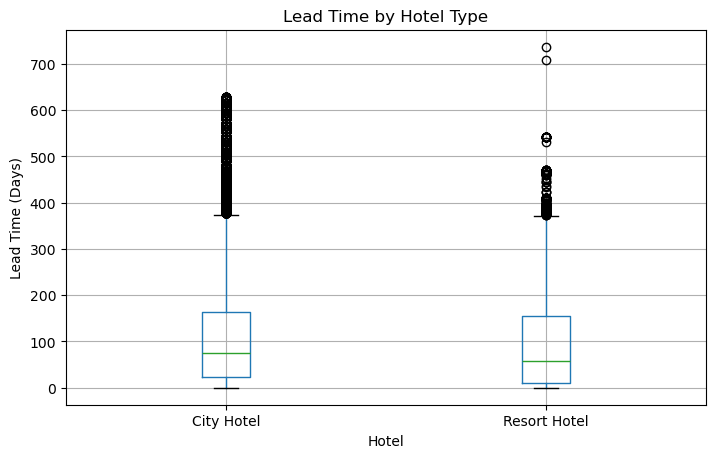

In [175]:
import matplotlib.pyplot as plt

df_hotel.boxplot(column="lead_time", by="hotel", figsize=(8,5))
plt.title("Lead Time by Hotel Type")
plt.suptitle("")
plt.xlabel("Hotel")
plt.ylabel("Lead Time (Days)")
plt.show()

___
* *City Hotel shows a higher lead time than Resort Hotel, both in mean and median values, which suggests that bookings for City Hotel are generally made further in advance. At the same time, both hotel types present very high maximum values and many outliers, indicating that some guests book several months, and in some cases even nearly two years, before arrival. The presence of 0-day lead times also shows that same-day bookings exist in both hotel types.*
___

### 2.2 Cancellation Rate by Hotel Type

In [179]:
df_hotel.groupby("hotel")["is_canceled"].mean() * 100

hotel
City Hotel      41.785935
Resort Hotel    27.767373
Name: is_canceled, dtype: float64

___
* City Hotel shows a significantly higher cancellation rate than Resort Hotel, suggesting that bookings in the city property are more likely to be canceled and may require stricter booking or deposit policies
___

### 2.3 Market Segment and Cancellations

In [183]:
# Booking volume and cancellation rate by market segment
market_segment_summary = (
    df_hotel.groupby(["hotel", "market_segment"])
    .agg(
        total_bookings=("is_canceled", "count"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

market_segment_summary["cancellation_rate"] = market_segment_summary["cancellation_rate"] * 100
market_segment_summary.sort_values(["hotel", "cancellation_rate"], ascending=[True, False])

,hotel,market_segment,total_bookings,cancellation_rate
7,City Hotel,Undefined,2,100.000000
4,City Hotel,Groups,13959,68.916111
5,City Hotel,Offline TA/TO,16712,42.879368
6,City Hotel,Online TA,38679,37.454433
0,City Hotel,Aviation,235,22.127660
2,City Hotel,Corporate,2977,21.498153
3,City Hotel,Direct,6072,17.391304
1,City Hotel,Complementary,527,10.626186
11,Resort Hotel,Groups,5832,42.421125
13,Resort Hotel,Online TA,17729,35.241694


_____
* market_segment represents the commercial source or customer category from which the booking originated. It helps identify whether a reservation came from channels such as online travel agencies, offline travel agencies or tour operators, direct bookings, corporate clients, group bookings, aviation-related bookings, or complimentary stays.
____

### 2.4 Deposit Type and Reservation Status

In [187]:
# Deposit type analysis: booking volume and cancellation rate by hotel type
deposit_summary = (
    df_hotel.groupby(["hotel", "deposit_type"])
    .agg(
        total_bookings=("is_canceled", "count"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

deposit_summary["cancellation_rate"] = deposit_summary["cancellation_rate"] * 100
deposit_summary.sort_values(["hotel", "cancellation_rate"], ascending=[True, False])

,hotel,deposit_type,total_bookings,cancellation_rate
1,City Hotel,Non Refund,12868,99.813491
2,City Hotel,Refundable,20,70.000000
0,City Hotel,No Deposit,66275,30.510751
4,Resort Hotel,Non Refund,1719,95.986038
3,Resort Hotel,No Deposit,38186,24.742052
5,Resort Hotel,Refundable,142,15.492958


___
* No Deposit bookings represent the largest share of reservations and show moderate cancellation rates in both hotels. Non Refund bookings, despite being associated with stricter deposit policies, show extremely high cancellation rates, which suggests that this category should be interpreted carefully. Refundable bookings have very low volume, so they are not reliable enough for strong conclusions *.
___

In [190]:
# Deposit type vs reservation status by hotel
pd.crosstab(
    [df_hotel["hotel"], df_hotel["deposit_type"]],
    df_hotel["reservation_status"],
    normalize="index"
) * 100

reservation_status          Canceled  Check-Out   No-Show
hotel        deposit_type                                
City Hotel   No Deposit    29.154281  69.489249  1.356469
             Non Refund    99.689151   0.186509  0.124339
             Refundable    70.000000  30.000000  0.000000
Resort Hotel No Deposit    24.029749  75.257948  0.712303
             Non Refund    94.938918   4.013962  1.047120
             Refundable    14.788732  84.507042  0.704225

___
* The cross-tab confirms that Non Refund bookings are overwhelmingly linked to canceled reservation statuses in both hotel types. This suggests that the category likely follows a particular operational or business rule in the dataset and should be interpreted with caution. Meanwhile, No Deposit bookings show a more regular pattern, with most reservations ending in check-out and a lower cancellation share, especially in Resort Hotel.
___

### 2.5 Customer Type and Cancellations

In [194]:
# Customer type analysis: booking volume and cancellation rate by hotel type
customer_summary = (
    df_hotel.groupby(["hotel", "customer_type"])
    .agg(
        total_bookings=("is_canceled", "count"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

customer_summary["cancellation_rate"] = customer_summary["cancellation_rate"] * 100
customer_summary.sort_values(["hotel", "cancellation_rate"], ascending=[True, False])

,hotel,customer_type,total_bookings,cancellation_rate
0,City Hotel,Contract,2296,48.127178
2,City Hotel,Transient,59272,45.685990
3,City Hotel,Transient-Party,17304,28.120666
1,City Hotel,Group,291,9.965636
6,Resort Hotel,Transient,30204,31.171368
7,Resort Hotel,Transient-Party,7784,19.514388
5,Resort Hotel,Group,283,10.247350
4,Resort Hotel,Contract,1776,8.840090


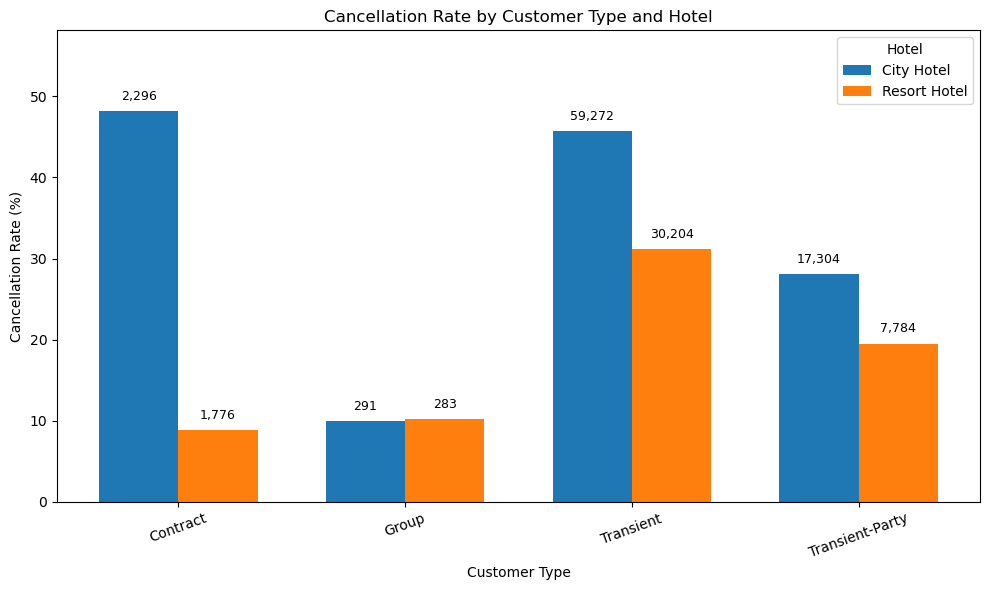

In [196]:
# Pivot cancellation rate
rate_pivot = customer_summary.pivot(
    index="customer_type",
    columns="hotel",
    values="cancellation_rate"
)

# Pivot total bookings
bookings_pivot = customer_summary.pivot(
    index="customer_type",
    columns="hotel",
    values="total_bookings"
)

x = np.arange(len(rate_pivot.index))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, rate_pivot["City Hotel"], width, label="City Hotel")
bars2 = ax.bar(x + width/2, rate_pivot["Resort Hotel"], width, label="Resort Hotel")

# Add booking volume labels on top of bars
for i, bar in enumerate(bars1):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{int(bookings_pivot.loc[rate_pivot.index[i], "City Hotel"]):,}',
        ha="center",
        va="bottom",
        fontsize=9
    )

for i, bar in enumerate(bars2):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{int(bookings_pivot.loc[rate_pivot.index[i], "Resort Hotel"]):,}',
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Cancellation Rate by Customer Type and Hotel")
ax.set_xlabel("Customer Type")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(rate_pivot.index, rotation=20)
ax.legend(title="Hotel")
ax.set_ylim(0, max(rate_pivot.max()) + 10)

plt.tight_layout()
plt.show()

___
* Transient customers generate the highest booking volume in both hotel types and also show relatively high cancellation rates, especially in City Hotel. Contract bookings behave very differently across hotel types, with high cancellation in City Hotel and low cancellation in Resort Hotel. Overall, City Hotel appears to have a less stable booking pattern across customer types.
___


## 3. Revenue and Value Drivers
This section uses ADR as a proxy for booking value to identify the most valuable hotel segments and channels

*Note: ADR is used as a proxy for booking value, but it does not fully capture total revenue, stay length, cancellation risk, or channel costs.*._


### 3.1 ADR by Hotel Type

In [201]:
# ADR summary by hotel type
df_hotel.groupby("hotel")["adr"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
hotel,,,,
City Hotel,105.503191,99.96,0.00,5400.0
Resort Hotel,94.983054,75.00,-6.38,508.0


### 3.2 ADR by Market Segment

In [204]:
# ADR by market segment and hotel type
adr_segment_summary = (
    df_hotel.groupby(["hotel", "market_segment"])
    .agg(
        total_bookings=("adr", "count"),
        avg_adr=("adr", "mean"),
        median_adr=("adr", "median")
    )
    .reset_index()
)

adr_segment_summary.sort_values(["hotel", "avg_adr"], ascending=[True, False])

,hotel,market_segment,total_bookings,avg_adr,median_adr
3,City Hotel,Direct,6072,119.833712,111.6
6,City Hotel,Online TA,38679,119.099009,114.0
0,City Hotel,Aviation,235,100.994383,95.0
5,City Hotel,Offline TA/TO,16712,93.199250,90.0
4,City Hotel,Groups,13959,85.018981,75.0
2,City Hotel,Corporate,2977,83.368915,79.0
7,City Hotel,Undefined,2,15.000000,15.0
1,City Hotel,Complementary,527,2.674440,0.0
13,Resort Hotel,Online TA,17729,113.432480,95.0
10,Resort Hotel,Direct,6510,111.718000,93.0


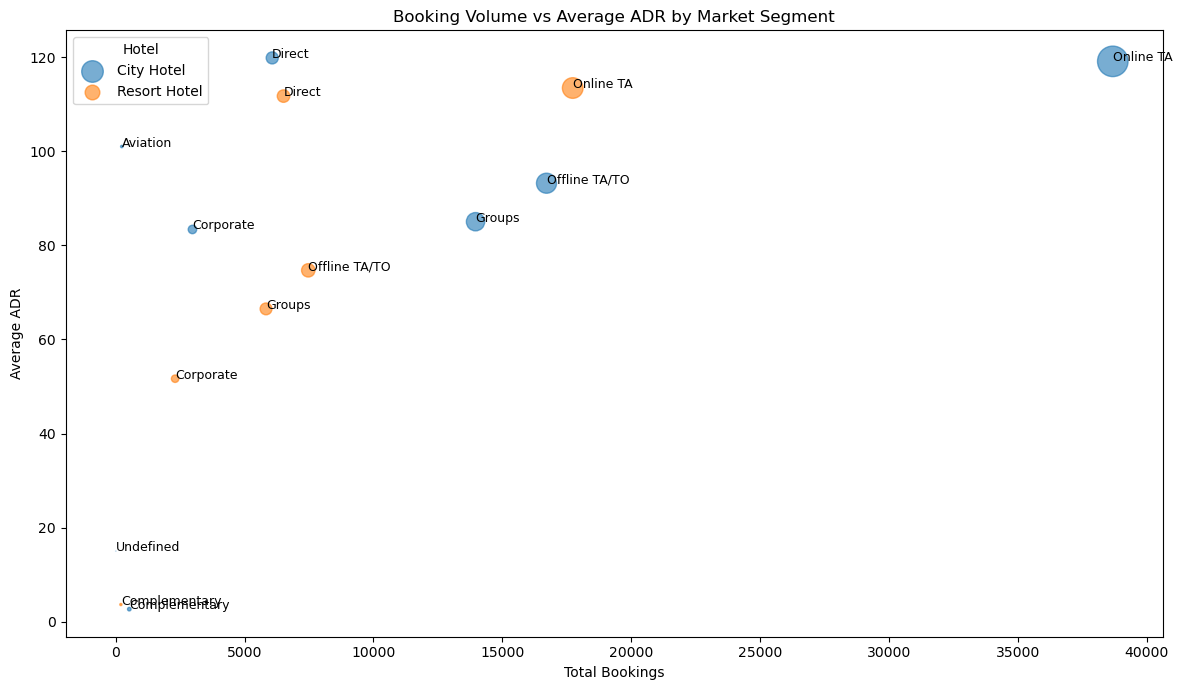

In [206]:
# Bubble chart: booking volume vs average ADR by market segment
fig, ax = plt.subplots(figsize=(12, 7))

for hotel in adr_segment_summary["hotel"].unique():
    data = adr_segment_summary[adr_segment_summary["hotel"] == hotel]
    
    ax.scatter(
        data["total_bookings"],
        data["avg_adr"],
        s=data["total_bookings"] / 80,   # bubble size
        alpha=0.6,
        label=hotel
    )
    
    for _, row in data.iterrows():
        ax.text(
            row["total_bookings"],
            row["avg_adr"],
            row["market_segment"],
            fontsize=9
        )

ax.set_title("Booking Volume vs Average ADR by Market Segment")
ax.set_xlabel("Total Bookings")
ax.set_ylabel("Average ADR")
ax.legend(title="Hotel")
plt.tight_layout()
plt.show()

___
* ADR analysis by market segment shows that Online TA and Direct bookings generate the highest room value in both hotel types. Online TA stands out as the most commercially important segment, since it combines high ADR with the largest booking volume, especially in City Hotel.
___

### 3.3 ADR by Distribution Channel

In [210]:
# ADR by distribution channel and hotel type
adr_channel_summary = (
    df_hotel.groupby(["hotel", "distribution_channel"])
    .agg(
        total_bookings=("adr", "count"),
        avg_adr=("adr", "mean"),
        median_adr=("adr", "median")
    )
    .reset_index()
)

adr_channel_summary.sort_values(["hotel", "avg_adr"], ascending=[True, False])

,hotel,distribution_channel,total_bookings,avg_adr,median_adr
2,City Hotel,GDS,193,120.554301,115.0
1,City Hotel,Direct,6749,111.264138,107.1
3,City Hotel,TA/TO,68831,105.896030,100.0
0,City Hotel,Corporate,3386,85.266480,80.0
4,City Hotel,Undefined,4,29.625000,15.0
8,Resort Hotel,Undefined,1,112.700000,112.7
6,Resort Hotel,Direct,7862,103.110296,80.0
7,Resort Hotel,TA/TO,28919,97.474166,80.0
5,Resort Hotel,Corporate,3265,53.343060,45.0


____
* Distribution channel analysis shows that TA/TO is the most commercially significant channel in both hotels, as it combines the highest booking volume with solid ADR levels. Direct bookings also generate strong ADR, especially in City Hotel, while Corporate bookings tend to produce lower room value.
____

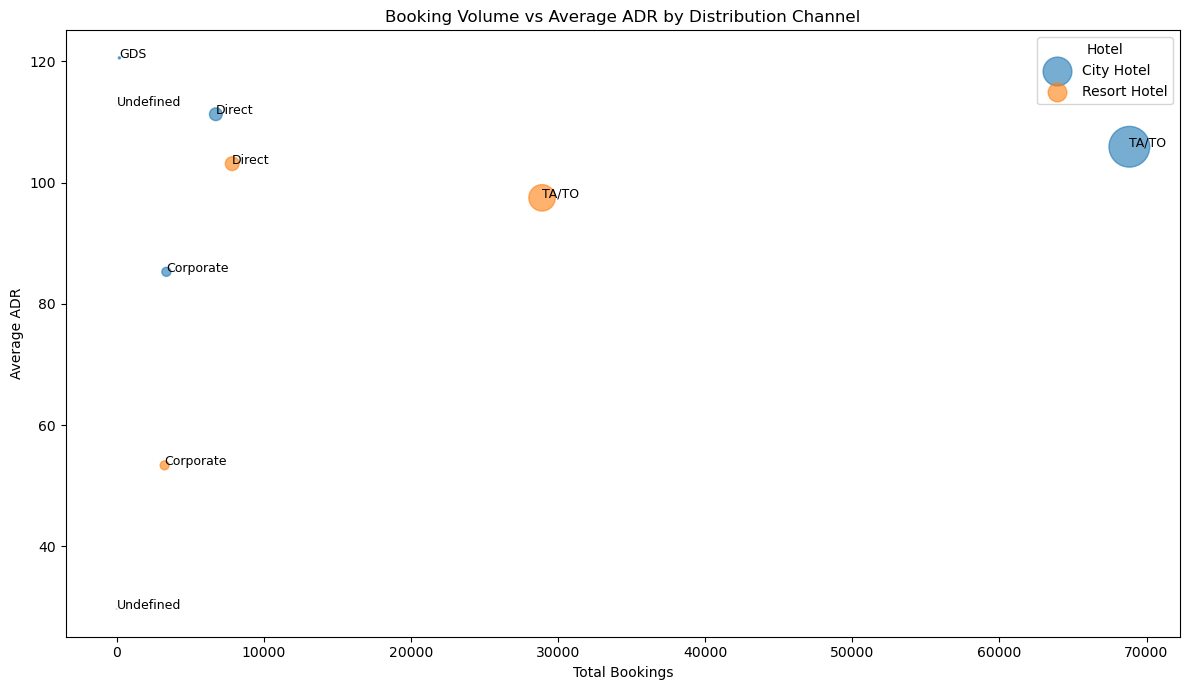

In [213]:
# Bubble chart: booking volume vs average ADR by distribution channel
fig, ax = plt.subplots(figsize=(12, 7))

for hotel in adr_channel_summary["hotel"].unique():
    data = adr_channel_summary[adr_channel_summary["hotel"] == hotel]
    
    ax.scatter(
        data["total_bookings"],
        data["avg_adr"],
        s=data["total_bookings"] / 80,
        alpha=0.6,
        label=hotel
    )
    
    for _, row in data.iterrows():
        ax.text(
            row["total_bookings"],
            row["avg_adr"],
            row["distribution_channel"],
            fontsize=9
        )

ax.set_title("Booking Volume vs Average ADR by Distribution Channel")
ax.set_xlabel("Total Bookings")
ax.set_ylabel("Average ADR")
ax.legend(title="Hotel")

plt.tight_layout()
plt.show()

____
* This bubble chart compares booking volume and average ADR across distribution channels for both hotel types. The horizontal axis shows total bookings, while the vertical axis shows average daily rate (ADR). Larger bubbles indicate higher booking volume. The chart helps identify which channels combine strong demand with higher room value. In this case, TA/TO stands out as the most commercially important channel due to its high booking volume and solid ADR, while Direct also shows strong value, especially in City Hotel.
____

## 4. Operational Insights
This section explores operational patterns that may affect service, booking quality, and revenue.

### 4.1 Length of Stay

In [218]:
# Total stay length
df_hotel["total_nights"] = df_hotel["stays_in_weekend_nights"] + df_hotel["stays_in_week_nights"]

df_hotel.groupby("hotel")["total_nights"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
hotel,,,,
City Hotel,2.974938,3.0,0,48
Resort Hotel,4.318376,3.0,0,69


### 4.2 Special Requests

In [221]:
# Special requests summary by hotel
df_hotel.groupby("hotel")["total_of_special_requests"].agg(["mean", "median", "min", "max"])

# Cancellation rate by number of special requests
(df_hotel.groupby(["hotel", "total_of_special_requests"])["is_canceled"].mean() * 100).reset_index()

,hotel,total_of_special_requests,is_canceled
0,City Hotel,0,55.001776
1,City Hotel,1,22.075127
2,City Hotel,2,21.403077
3,City Hotel,3,17.613636
4,City Hotel,4,10.606061
5,City Hotel,5,3.846154
6,Resort Hotel,0,32.280294
7,Resort Hotel,1,21.997290
8,Resort Hotel,2,23.347835
9,Resort Hotel,3,18.241758


### 4.3 Reserved vs Assigned Room Type

In [224]:
# Room assignment change
df_hotel["room_changed"] = df_hotel["reserved_room_type"] != df_hotel["assigned_room_type"]

(df_hotel["room_changed"].value_counts(normalize=True) * 100)

# Cancellation rate by room change
(df_hotel.groupby(["hotel", "room_changed"])["is_canceled"].mean() * 100).reset_index()

,hotel,room_changed,is_canceled
0,City Hotel,False,45.310397
1,City Hotel,True,5.891495
2,Resort Hotel,False,33.208574
3,Resort Hotel,True,4.975382


____
**Total nights:** Resort Hotel shows a longer average stay than City Hotel, suggesting that resort guests tend to stay for more nights, even though the typical stay is around 3 nights in both hotel types.

**Special requests:** Cancellation rates generally decrease as the number of special requests increases, suggesting that guests who make more requests are more engaged and less likely to cancel.

**Room change:** Bookings with a changed room assignment show much lower cancellation rates in both hotels, although this likely reflects operational timing rather than a direct cause of lower cancellations.
____

____

### 4.4 Parking Demand_

In [228]:
# Parking analysis: booking volume, cancellation rate, and ADR by hotel type
parking_summary = (
    df_hotel.groupby(["hotel", "required_car_parking_spaces"])
    .agg(
        total_bookings=("is_canceled", "count"),
        cancellation_rate=("is_canceled", "mean"),
        avg_adr=("adr", "mean")
    )
    .reset_index()
)

parking_summary["cancellation_rate"] = parking_summary["cancellation_rate"] * 100
parking_summary.sort_values(["hotel", "required_car_parking_spaces"])

,hotel,required_car_parking_spaces,total_bookings,cancellation_rate,avg_adr
0,City Hotel,0,77243,42.824593,105.091173
1,City Hotel,1,1915,0.000000,121.924480
2,City Hotel,2,3,0.000000,218.966667
3,City Hotel,3,2,0.000000,124.665000
4,Resort Hotel,0,34558,32.177788,92.577008
5,Resort Hotel,1,5461,0.000000,110.172921
6,Resort Hotel,2,25,0.000000,104.992400
7,Resort Hotel,3,1,0.000000,111.000000
8,Resort Hotel,8,2,0.000000,60.000000


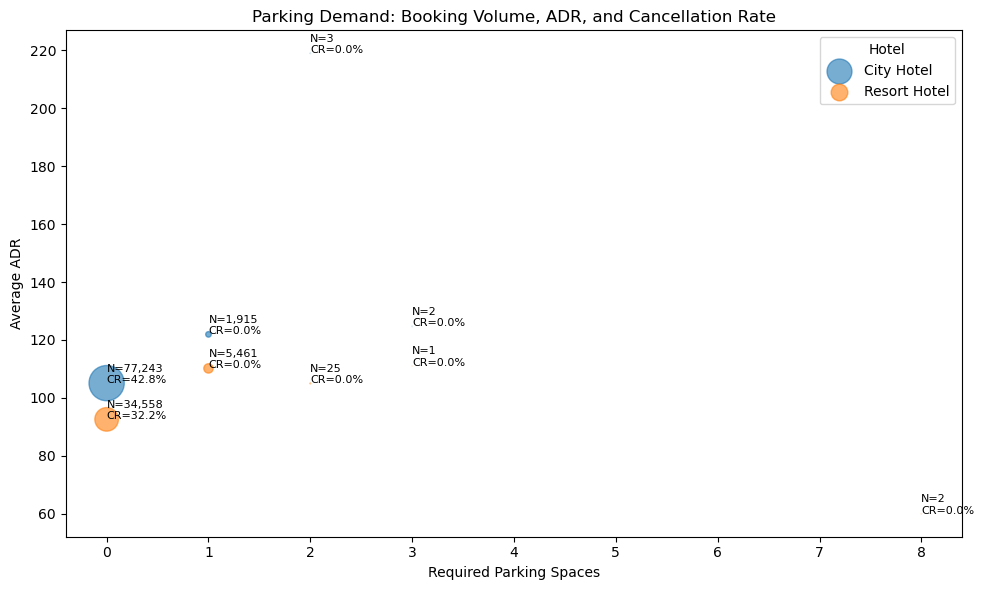

In [230]:
fig, ax = plt.subplots(figsize=(10, 6))

for hotel in parking_summary["hotel"].unique():
    data = parking_summary[parking_summary["hotel"] == hotel]
    
    ax.scatter(
        data["required_car_parking_spaces"],
        data["avg_adr"],
        s=data["total_bookings"] / 120,
        alpha=0.6,
        label=hotel
    )
    
    for _, row in data.iterrows():
        ax.text(
            row["required_car_parking_spaces"],
            row["avg_adr"],
            f'N={int(row["total_bookings"]):,}\nCR={row["cancellation_rate"]:.1f}%',
            fontsize=8
        )

ax.set_title("Parking Demand: Booking Volume, ADR, and Cancellation Rate")
ax.set_xlabel("Required Parking Spaces")
ax.set_ylabel("Average ADR")
ax.legend(title="Hotel")
plt.tight_layout()
plt.show()

____
* Parking demand appears to be associated with more stable and higher-value bookings, although the zero-cancellation pattern suggests this result should be interpreted carefully. Guest composition also reveals important operational differences: family bookings generate higher ADR and longer stays in both hotels, making them more valuable overall, although their cancellation behavior differs between City Hotel and Resort Hotel.
____

### 4.5 Guest Composition

In [234]:
# Guest composition
df_hotel["guest_composition"] = np.where(
    (df_hotel["children"] > 0) | (df_hotel["babies"] > 0),
    "Family",
    "Adults Only"
)

guest_summary = (
    df_hotel.groupby(["hotel", "guest_composition"])
    .agg(
        total_bookings=("is_canceled", "count"),
        cancellation_rate=("is_canceled", "mean"),
        avg_adr=("adr", "mean"),
        avg_total_nights=("total_nights", "mean")
    )
    .reset_index()
)

guest_summary["cancellation_rate"] = guest_summary["cancellation_rate"] * 100
guest_summary.sort_values(["hotel", "cancellation_rate"], ascending=[True, False])

,hotel,guest_composition,total_bookings,cancellation_rate,avg_adr,avg_total_nights
0,City Hotel,Adults Only,73760,42.322397,102.276340,2.948156
1,City Hotel,Family,5403,34.462336,149.555099,3.340552
3,Resort Hotel,Family,3929,35.556121,161.144927,4.753118
2,Resort Hotel,Adults Only,36118,26.920095,87.785812,4.271084


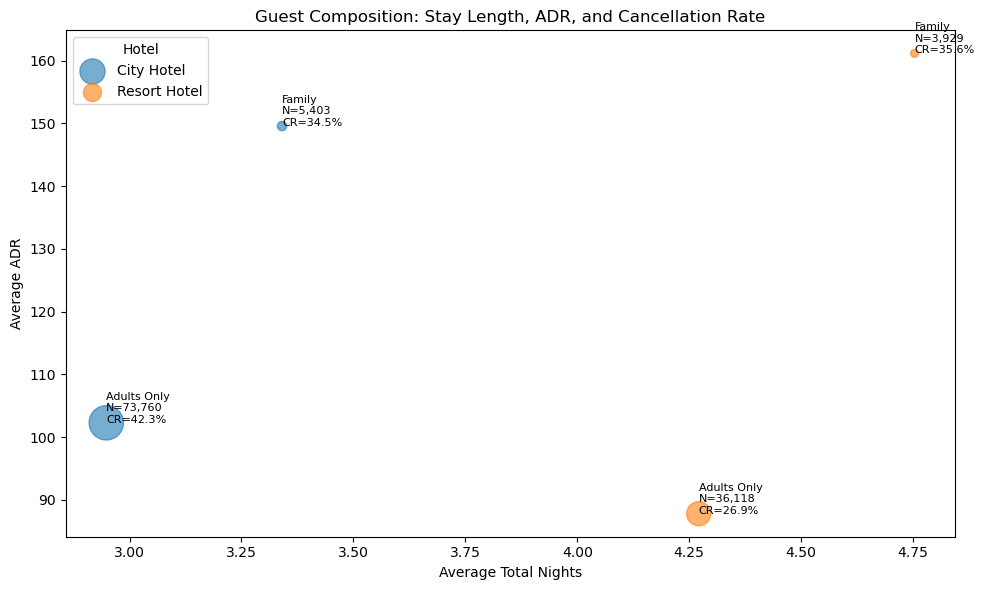

In [246]:
fig, ax = plt.subplots(figsize=(10, 6))

for hotel in guest_summary["hotel"].unique():
    data = guest_summary[guest_summary["hotel"] == hotel]
    
    ax.scatter(
        data["avg_total_nights"],
        data["avg_adr"],
        s=data["total_bookings"] / 120,
        alpha=0.6,
        label=hotel
    )
    
    for _, row in data.iterrows():
        ax.text(
            row["avg_total_nights"],
            row["avg_adr"],
            f'{row["guest_composition"]}\nN={int(row["total_bookings"]):,}\nCR={row["cancellation_rate"]:.1f}%',
            fontsize=8
        )

ax.set_title("Guest Composition: Stay Length, ADR, and Cancellation Rate")
ax.set_xlabel("Average Total Nights")
ax.set_ylabel("Average ADR")
ax.legend(title="Hotel")
plt.tight_layout()
plt.show()

____
* *Operationally, Resort Hotel tends to attract longer stays, while special requests and parking demand are associated with more stable and often higher-value bookings. Guest composition also matters, as family bookings tend to generate higher ADR and longer stays.*
____


# Final Conclusions and Recommendations


## Key Conclusions

- City Hotel shows higher booking volume, ADR, and cancellation risk than Resort Hotel.
- August is the strongest demand month for both hotel types, while January is the weakest.
- Online TA and Direct bookings generate the strongest ADR performance among segments.
- TA/TO is the most commercially important distribution channel due to its strong volume and ADR combination.
- Family bookings tend to produce higher ADR and longer stays, while special requests are associated with lower cancellation rates.

## Business Recommendations
3 recomendations

- Strengthen cancellation management strategies for City Hotel, especially for high-risk segments.
- Prioritize high-value channels such as Online TA, Direct, and TA/TO while monitoring their cancellation behavior.
- Use operational signals such as special requests, parking demand, and guest composition to improve forecasting and service planning.


## Limitations
- ADR is used as a proxy for booking value rather than total revenue.
- Some extreme ADR values may reflect outliers.
- The dataset does not include a unique booking identifier.
